In [1]:
# ==========================================
# Cars Price Prediction - Linear Regression
# ==========================================
# Import required libraries:
# - pandas: data manipulation and analysis
# - sklearn: machine learning utilities
# - seaborn: statistical data visualization
# - preprocessing tools: for data scaling/normalization
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
import seaborn as sb
from sklearn.preprocessing import scale,minmax_scale,normalize

In [2]:
# Load the dataset from CSV file
# encoding='latin1' handles special characters in the file
# Display the first 5 rows to inspect the raw data
data=pd.read_csv("Cars Datasets 2025.csv",encoding='latin1')
data.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [3]:
# Drop the 'Cars Names' column as it is a non-numeric identifier
# that does not contribute to price prediction
data.drop(columns='Cars Names',inplace=True)

In [4]:
# Rename columns to shorter, more convenient names for easier access:
# - 'Company Names' -> 'company_names'
# - 'CC/Battery Capacity' -> 'battery(CC)'
# - 'Performance(0-100)KM/H' -> '0_100'
# - 'Cars Prices' -> 'prices'
data.rename(columns={'Company Names':'company_names','CC/Battery Capacity':'battery(CC)','Performance(0 - 100 )KM/H':'0_100',\
'Cars Prices':'prices'},inplace=True)

In [5]:
# Verify column renaming by displaying the first 5 rows again
data.head()

,company_names,Engines,battery(CC),HorsePower,Total Speed,0_100,prices,Fuel Types,Seats,Torque
0,FERRARI,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [6]:
# Label encode 'company_names' column:
# Convert categorical company names to numeric values
# so they can be used in the regression model
l={}
s=set(data['company_names'])
for i,j in enumerate(s):
    l.update({j:i})
data.replace(l,inplace=True)    

C:\Users\Pourya\AppData\Local\Temp\ipykernel_8384\730624084.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(l,inplace=True)


In [7]:
# Display the data after encoding company names
# (company names are now represented as integers)
data.head()

,company_names,Engines,battery(CC),HorsePower,Total Speed,0_100,prices,Fuel Types,Seats,Torque
0,17,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,26,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,27,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,33,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,16,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [8]:
# Check for duplicate rows in the dataset
data.duplicated().sum()

np.int64(38)

In [9]:
# Remove duplicate rows and reset the index
data.drop_duplicates(inplace=True,ignore_index=True)

In [10]:
# Check for missing (NaN) values in each column
data.isnull().sum()

company_names    0
Engines          0
battery(CC)      3
HorsePower       0
Total Speed      0
0_100            6
prices           0
Fuel Types       0
Seats            0
Torque           1
dtype: int64

In [11]:
# Drop rows that contain any missing values
# and reset the index to maintain continuity
data.dropna(inplace=True,ignore_index=True)

In [12]:
# Display the cleaned dataset
data

,company_names,Engines,battery(CC),HorsePower,Total Speed,0_100,prices,Fuel Types,Seats,Torque
0,17,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,26,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,27,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,33,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,16,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm
...,...,...,...,...,...,...,...,...,...,...
1167,18,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,"$43,590  $48,000",Hybrid (Gas + Electric),5,239 Nm
1168,18,2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,"$50,000",Hybrid,7,630 Nm
1169,18,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190 km/h,8.0  9.2 sec,"$25,210  $29,135",Gas / Hybrid,5,190  210 Nm
1170,18,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180 km/h,7.9  10.5 sec," 33,000",Hybrid,5,190  205 Nm


In [13]:
# Manually drop specific rows (indices 1167-1171)
# These rows were identified as problematic/noisy entries
# (e.g., multi-range values like '169 196 hp', '8.0 9.2 sec')
data.drop(index=1167,inplace=True)
data.drop(index=1168,inplace=True)
data.drop(index=1169,inplace=True)
data.drop(index=1170,inplace=True)
data.drop(index=1171,inplace=True)

In [14]:
# Clean the 'battery(CC)' column:
# Remove unit strings ('cc', 'kwh', 'kWh', etc.) and whitespace/commas
# so the column can later be converted to numeric type
data['battery(CC)']=data['battery(CC)'].str.replace('cc','',regex=False)
data['battery(CC)']=data['battery(CC)'].str.replace(' ','',regex=False)
data['battery(CC)']=data['battery(CC)'].str.replace(',','',regex=False)
data['battery(CC)']=data['battery(CC)'].str.replace('kwh','',regex=False)
data['battery(CC)']=data['battery(CC)'].str.replace('kWhBattery','',regex=False)
data['battery(CC)']=data['battery(CC)'].str.replace('kWh','',regex=False)
data['battery(CC)']=data['battery(CC)'].str.replace('(petrol)+ElectricMotor','',regex=False)

In [15]:
# Clean the 'HorsePower' column:
# Remove unit strings ('hp', 'HP') and whitespace/commas
data['HorsePower']=data['HorsePower'].str.replace('hp','',regex=False)
data['HorsePower']=data['HorsePower'].str.replace(' ','',regex=False)
data['HorsePower']=data['HorsePower'].str.replace(',','',regex=False)
data['HorsePower']=data['HorsePower'].str.replace('HP','',regex=False)

In [16]:
# Clean the 'Total Speed' column:
# Remove the 'km/h' unit string and extra whitespace
data['Total Speed']=data['Total Speed'].str.replace('km/h','',regex=False)
data['Total Speed']=data['Total Speed'].str.replace(' ','',regex=False)

In [17]:
# Clean the '0_100' (0-100 km/h acceleration) column:
# Remove the 'sec' unit string and extra whitespace
data['0_100']=data['0_100'].str.replace('sec','',regex=False)
data['0_100']=data['0_100'].str.replace(' ','',regex=False)

In [18]:
# Clean the 'prices' column:
# Remove dollar sign, spaces, and commas
data['prices']=data['prices'].str.replace('$','',regex=False)
data['prices']=data['prices'].str.replace(' ','',regex=False)
data['prices']=data['prices'].str.replace(',','',regex=False)

In [19]:
# Split the 'prices' column into 'price_min' and 'price_max'
# since some entries have a price range (e.g., '$12,000-$15,000')
data[['price_min','price_max']]=data['prices'].str.split('-',expand=True)

In [20]:
# Drop the original 'prices' and 'price_max' columns
# We keep only the minimum price as our prediction target
data.drop(columns=['prices','price_max'],inplace=True)

In [21]:
# Rename 'price_min' back to 'prices' for clarity
data.rename(columns={'price_min':'prices'},inplace=True)

In [22]:
# Clean the 'Torque' column:
# Remove the 'Nm' unit string and extra whitespace
data['Torque']=data['Torque'].str.replace('Nm','',regex=False)
data['Torque']=data['Torque'].str.replace(' ','',regex=False)

In [23]:
# Display the dataset after all string cleaning steps
data

,company_names,Engines,battery(CC),HorsePower,Total Speed,0_100,Fuel Types,Seats,Torque,prices
0,17,V8,3990,963,340,2.5,plug in hyrbrid,2,800,1100000
1,26,V12,6749,563,250,5.3,Petrol,5,900,460000
2,27,1.2L Petrol,1200,70-85,165,10.5,Petrol,5,100-140,12000
3,33,V8,3982,630,250,3.2,Petrol,4,900,161000
4,16,V10,5204,602,320,3.6,Petrol,2,560,253290
...,...,...,...,...,...,...,...,...,...,...
1162,23,2.0L Inline-4,1998,120,130,15.0,Petrol,2,150,15000
1163,23,1.3L Wankel Rotary Engine,1308,130,150,14.5,Petrol,2,160,18000
1164,23,1.3L Wankel Rotary Engine,1308,135,175,12.0,Petrol,4,180,25000
1165,23,2.5L V6,2500,200,220,8.0,Petrol,5,250,30000


In [24]:
# Convert 'Torque' column to numeric type
# errors='coerce' turns invalid/unparseable entries into NaN
data['Torque']=pd.to_numeric(data['Torque'],errors='coerce')

In [25]:
# Recheck for NaN values after converting Torque to numeric
# (some entries with ranges like '100-140' will become NaN)
data.isnull().sum()

company_names     0
Engines           0
battery(CC)       0
HorsePower        0
Total Speed       0
0_100             0
Fuel Types        0
Seats             0
Torque           42
prices            0
dtype: int64

In [26]:
# Drop remaining rows with NaN values (from failed numeric conversion)
data.dropna(inplace=True)

In [27]:
# Display the dataset after dropping NaN rows
data

,company_names,Engines,battery(CC),HorsePower,Total Speed,0_100,Fuel Types,Seats,Torque,prices
0,17,V8,3990,963,340,2.5,plug in hyrbrid,2,800.0,1100000
1,26,V12,6749,563,250,5.3,Petrol,5,900.0,460000
3,33,V8,3982,630,250,3.2,Petrol,4,900.0,161000
4,16,V10,5204,602,320,3.6,Petrol,2,560.0,253290
5,8,V8,3994,710,341,2.9,Petrol,2,770.0,499000
...,...,...,...,...,...,...,...,...,...,...
1162,23,2.0L Inline-4,1998,120,130,15.0,Petrol,2,150.0,15000
1163,23,1.3L Wankel Rotary Engine,1308,130,150,14.5,Petrol,2,160.0,18000
1164,23,1.3L Wankel Rotary Engine,1308,135,175,12.0,Petrol,4,180.0,25000
1165,23,2.5L V6,2500,200,220,8.0,Petrol,5,250.0,30000


In [28]:
# Label encode 'Fuel Types' column:
# Convert categorical fuel type names to numeric values
l={}
s=set(data['Fuel Types'])
for i,j in enumerate(s):
    l.update({j:i})
data.replace(l,inplace=True) 

C:\Users\Pourya\AppData\Local\Temp\ipykernel_8384\2725172208.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(l,inplace=True)


In [29]:
# Label encode 'Engines' column:
# Convert categorical engine type names to numeric values
l={}
s=set(data['Engines'])
for i,j in enumerate(s):
    l.update({j:i})
data.replace(l,inplace=True) 

C:\Users\Pourya\AppData\Local\Temp\ipykernel_8384\4248559626.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(l,inplace=True)


In [30]:
# Display the fully encoded dataset (all columns are now numeric)
data

,company_names,Engines,battery(CC),HorsePower,Total Speed,0_100,Fuel Types,Seats,Torque,prices
0,17,296,3990,963,340,2.5,5,2,800.0,1100000
1,26,242,6749,563,250,5.3,14,5,900.0,460000
3,33,296,3982,630,250,3.2,14,4,900.0,161000
4,16,211,5204,602,320,3.6,14,2,560.0,253290
5,8,296,3994,710,341,2.9,14,2,770.0,499000
...,...,...,...,...,...,...,...,...,...,...
1162,23,233,1998,120,130,15.0,14,2,150.0,15000
1163,23,284,1308,130,150,14.5,14,2,160.0,18000
1164,23,284,1308,135,175,12.0,14,4,180.0,25000
1165,23,182,2500,200,220,8.0,14,5,250.0,30000


In [31]:
# Convert remaining columns to numeric type using pd.to_numeric()
# errors='coerce' converts invalid entries to NaN
# This handles any remaining string values in numeric columns
data['battery(CC)']=pd.to_numeric(data['battery(CC)'],errors='coerce')
data['HorsePower']=pd.to_numeric(data['HorsePower'],errors='coerce')
data['Total Speed']=pd.to_numeric(data['Total Speed'],errors='coerce')
data['0_100']=pd.to_numeric(data['0_100'],errors='coerce')
data['Seats']=pd.to_numeric(data['Seats'],errors='coerce')
data['prices']=pd.to_numeric(data['prices'],errors='coerce')

In [32]:
# Check for NaN values after the final numeric conversion
data.isnull().sum()

company_names     0
Engines           0
battery(CC)      83
HorsePower       60
Total Speed       0
0_100             0
Fuel Types        0
Seats            10
Torque            0
prices            0
dtype: int64

In [33]:
# Drop remaining NaN rows and reset the index
data.dropna(inplace=True,ignore_index=True)

In [34]:
# Filter out extreme outlier values to improve model performance:
# - Torque < 1000 Nm
# - Total Speed < 350 km/h
# - Battery capacity < 8000 cc
# - HorsePower < 800 hp
# Reset the index of the filtered DataFrame
f=data[(data['Torque']<1000) & (data['Total Speed'] < 350) & (data['battery(CC)'] < 8000) &\
(data['HorsePower'] < 800)]
f.reset_index(inplace=True)

C:\Users\Pourya\AppData\Local\Temp\ipykernel_8384\2913719583.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(f['HorsePower'])


<Axes: xlabel='HorsePower', ylabel='Density'>

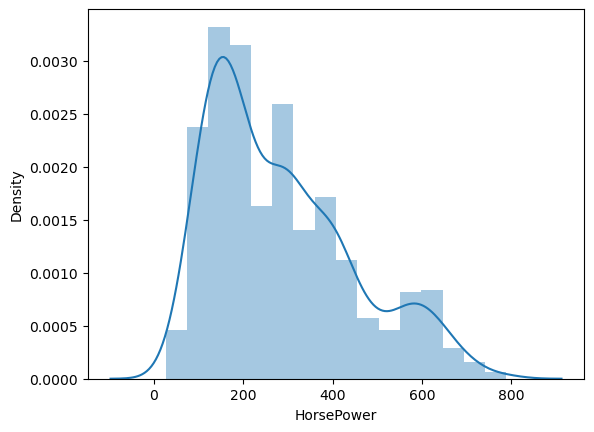

In [35]:
# Plot the distribution of HorsePower
# to understand the spread and skewness of this feature
sb.distplot(f['HorsePower'])

C:\Users\Pourya\AppData\Local\Temp\ipykernel_8384\2512468095.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(f['battery(CC)'])


<Axes: xlabel='battery(CC)', ylabel='Density'>

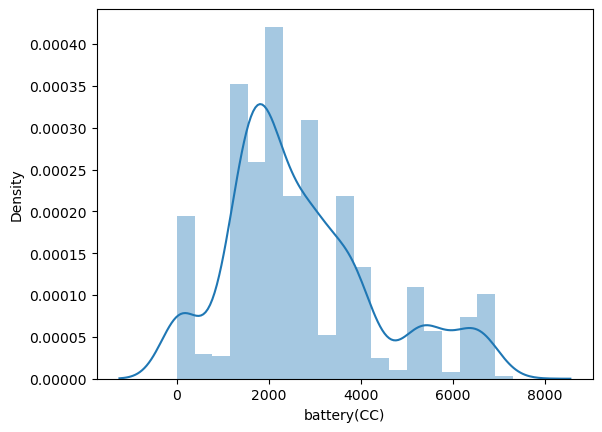

In [36]:
# Plot the distribution of Battery Capacity
sb.distplot(f['battery(CC)'])

C:\Users\Pourya\AppData\Local\Temp\ipykernel_8384\1896036712.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(f['Total Speed'])


<Axes: xlabel='Total Speed', ylabel='Density'>

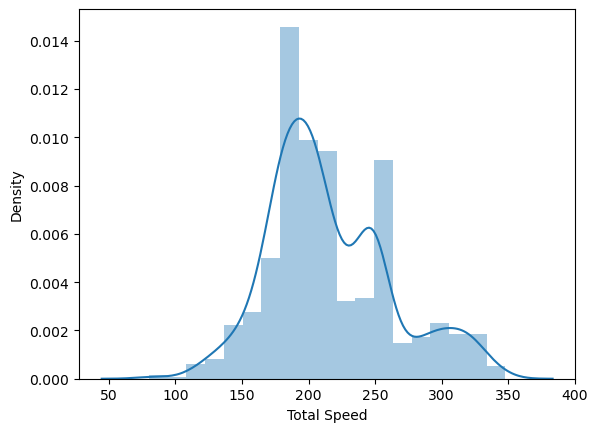

In [37]:
# Plot the distribution of Total Speed
sb.distplot(f['Total Speed'])

C:\Users\Pourya\AppData\Local\Temp\ipykernel_8384\3788597101.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(f['Torque'])


<Axes: xlabel='Torque', ylabel='Density'>

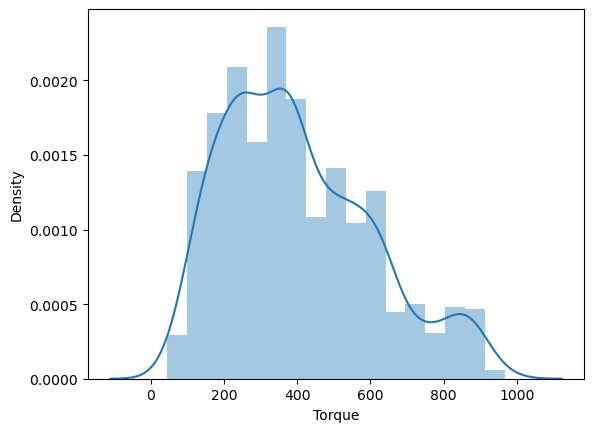

In [38]:
# Plot the distribution of Torque
sb.distplot(f['Torque'])

In [39]:
# Drop the temporary 'index' column created by reset_index()
# inplace=True modifies the DataFrame directly
f.drop(columns='index',inplace=True)

C:\Users\Pourya\AppData\Local\Temp\ipykernel_8384\427933567.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f.drop(columns='index',inplace=True)


In [40]:
# Display the final cleaned and filtered dataset
f.head()

,company_names,Engines,battery(CC),HorsePower,Total Speed,0_100,Fuel Types,Seats,Torque,prices
0,26,242,6749.0,563.0,250,5.3,14,5.0,900.0,460000
1,33,296,3982.0,630.0,250,3.2,14,4.0,900.0,161000
2,16,211,5204.0,602.0,320,3.6,14,2.0,560.0,253290
3,8,296,3994.0,710.0,341,2.9,14,2.0,770.0,499000
4,32,296,3982.0,656.0,314,3.6,14,2.0,685.0,193440


In [41]:
# Separate features (X) and target (y):
# X = all columns except the last one ('prices')
# y = 'prices' column (the value we want to predict)
# Print shapes to confirm dimensions
x=f.iloc[:,:-1]
y=f['prices']
print(x.shape,y.shape)

(953, 9) (953,)


In [42]:
# Split data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [43]:
# Verify the shapes of all four split datasets
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(762, 9) (762,) (191, 9) (191,)


In [44]:
# Initialize and train the Linear Regression model
# The model learns the relationship between car features and prices
reg=LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [45]:
# Generate predictions on the test set
# Calculate Mean Squared Error (MSE) to measure prediction error
# Lower MSE = better model performance
y_pre=reg.predict(x_test)
mse=mean_squared_error(y_test,y_pre)
mse

6214482499.54188

In [46]:
# Calculate R-squared (R2) score:
# Measures how well the model explains variance in the data
# Range: 0 to 1 (1 = perfect fit)
r=r2_score(y_test,y_pre)
r

0.4306452602805666

In [47]:
# Display the final cleaned dataset one more time for reference
f.head()

,company_names,Engines,battery(CC),HorsePower,Total Speed,0_100,Fuel Types,Seats,Torque,prices
0,26,242,6749.0,563.0,250,5.3,14,5.0,900.0,460000
1,33,296,3982.0,630.0,250,3.2,14,4.0,900.0,161000
2,16,211,5204.0,602.0,320,3.6,14,2.0,560.0,253290
3,8,296,3994.0,710.0,341,2.9,14,2.0,770.0,499000
4,32,296,3982.0,656.0,314,3.6,14,2.0,685.0,193440


In [48]:
# Test the model with a single custom car specification:
# [company_id=13, engine_id=216, battery=6749cc, hp=563,
#  speed=250km/h, 0-100=5.3s, fuel_id=1, seats=5, torque=900Nm]
# This predicts the price for a Rolls Royce Phantom-like configuration
y=reg.predict([[13,216,6749,563,250,5.3,1,5,900]])
y

C:\Users\Pourya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([161420.01012776])